# Entrenamiento de modelos

## Configuración del path

In [2]:
# Configuración del path del proyecto
# Permite importar módulos desde la carpeta raíz `Data-science`
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

# Se agrega la raíz del proyecto si aún no está incluida.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## Importacion de librerias

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from src.transformers import TextCleaner
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib


## Importación de dataset

In [4]:
# Importación del dataset
ruta = PROJECT_ROOT / 'data'/ '2_clean_data.csv'

# Leer el archivo
try:
    df_final = pd.read_csv(ruta, encoding='latin1', engine='python', on_bad_lines='skip')
    # Mostrar las primeras filas para verificar
    print("Archivo cargado exitosamente.")
    display(df_final.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {ruta}")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Archivo cargado exitosamente.


,Text,clean_text,sentiment
0,I have bought several of the Vitality canned d...,bought vitality canned dog food products good ...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,Negative
2,This is a confection that has been around a fe...,confection centuries light pillowy citrus gela...,Positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe g...,Negative
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,Positive


## Feature Engineering y entrenamiento de modelos

En esta etapa se realizará el feature engeineering, para el cual se realizará la vectorización del texto del dataset limpio, mediante TF-IDF.

Además, se entrenarán los modelos de Naive Bayes y Regresión Logística y se evaluarán las métricas para elegir el modelo que realiza una mejor clasificación de los comentarios.
Todos estos pasos estarán unidos en un pipeline para facilitar la ejecución de todas las etapas.

In [7]:
# Visualización del dataframe
df_final

,Text,clean_text,sentiment
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,Negative
2,This is a confection that has been around a fe...,confection around centuries light pillowy citr...,Positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...,Negative
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,Positive
...,...,...,...
568449,Great for sesame chicken..this is a good if no...,great sesame chickenthis good better resturant...,Positive
568450,I'm disappointed with the flavor. The chocolat...,im disappointed flavor chocolate notes especia...,Negative
568451,"These stars are small, so you can give 10-15 o...",stars small give one training session tried tr...,Positive
568452,These are the BEST treats for training and rew...,best treats training rewarding dog good groomi...,Positive


### Definición de Target y Features.

En esta etapa, se definen los Features y el Target del dataset final. 
- Feature: columna 'Text', que es el texto original que el modelo debe analizar.
- Target: columna 'sentiment' que es la clasificación que se le da al tono del texto del comentario (positivo, neutro o negativo).

Además, se separa el dataset en datos de prueba (test) y de entrenamiento (train) para poderlos utilizar en los modelos.

In [12]:
# 1. Definimos X (features) y y (target)
X = df_final['Text']
y = df_final['sentiment']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.to_frame(name="text")
X_test  = X_test.to_frame(name="text")


### Pipeline para modelo de Naive Bayes

En esta etapa, se crea un pipeline que incluye la vectorización del texto y la utilización de varios modelos de Naive Bayes con diferentes combinaciones de hiperparámetros para poder realizar la clasificación de los comentarios.

En el entrenamiento del modelo, se obtienen los hiperparámetros que tuvieron mejor rendimiento (mejor F1 score) para obtener el modelo final entrenado.

In [ ]:
# ======================================================
# Pipeline 1: TF-IDF + Naive Bayes
# ======================================================
# Este pipeline integra en un solo flujo:
# 1. Manejo de valores faltantes (NaN)
# 2. Limpieza y normalización del texto
# 3. Vectorización mediante TF-IDF
# 4. Entrenamiento de un clasificador Naive Bayes
#
# La ventaja de este enfoque es que todo el preprocesamiento
# se aprende únicamente a partir del conjunto de entrenamiento,
# evitando data leakage y facilitando la reutilización del modelo
# en entornos productivos (ej. backend o API).
# ======================================================

# Transformador personalizado para limpieza de texto
# Utiliza la función `full_clean`, definida previamente,
# que aplica normalización y eliminación de stopwords.
text_cleaner = FunctionTransformer(
    np.vectorize(full_clean),
    validate=False
)

# Definición del pipeline completo
pipeline_nb = Pipeline([

    # Paso 1: Imputación de valores faltantes
    # Los valores NaN se reemplazan por strings vacíos para evitar
    # errores en los pasos posteriores de procesamiento de texto.
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),

    # Paso 2: Limpieza del texto
    # Se aplica la normalización, eliminación de símbolos,
    # URLs y stopwords directamente sobre el texto crudo.
    ("cleaner", TextCleaner()),

    # Paso 3: Vectorización TF-IDF
    # Convierte el texto limpio en una representación numérica
    # basada en la importancia relativa de cada término.
    ("tfidf", TfidfVectorizer()),

    # Paso 4: Modelo de clasificación
    # Se utiliza Multinomial Naive Bayes
    ("clf", MultinomialNB())
])


# ======================================================
# Definición de la grilla de hiperparámetros
# ======================================================
# Se exploran diferentes configuraciones tanto del
# vectorizador TF-IDF como del clasificador Naive Bayes
# para encontrar la combinación que maximice el desempeño.
# ======================================================

param_grid_nb = {
    # Número máximo de términos considerados en el vocabulario
    'tfidf__max_features': [3000, 5000, 10000],

    # Uso de unigramas y bigramas para capturar contexto
    'tfidf__ngram_range': [(1,1), (1,2)],

    # Parámetro de suavizado de Laplace del modelo Naive Bayes
    'clf__alpha': [0.1, 0.5, 1.0]
}

# ======================================================
# Búsqueda de hiperparámetros con GridSearchCV
# ======================================================
# GridSearchCV evalúa todas las combinaciones posibles
# utilizando validación cruzada, seleccionando el modelo
# que obtiene el mejor desempeño promedio.
# ======================================================

grid_nb = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid_nb,
    cv=3,                # validación cruzada de 3 folds
    scoring='f1_macro',  # métrica para elegir la mejor configuración del modelo. Robusta para clases desbalanceadas.
    verbose=2,
    n_jobs=-1            # usa todos los núcleos disponibles
)


# ======================================================
# Entrenamiento del modelo
# ======================================================
# El pipeline completo (limpieza + vectorización + modelo)
# se entrena exclusivamente con el conjunto de entrenamiento.
# ======================================================
grid_nb.fit(X_train, y_train)


# ======================================================
# Resultados
# ======================================================
# Se muestran los mejores hiperparámetros encontrados
# durante el proceso de búsqueda.
# ======================================================
print("Mejores parámetros - Naive Bayes:", grid_nb.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=  25.1s
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=  22.4s
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=  23.3s
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=  25.8s
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=  24.7s
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=  23.6s
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=  22.7s
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=  26.8s
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=  22.9s
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_ra

Exception ignored in: <_io.BytesIO object at 0x0000014DC65A3F10>
Traceback (most recent call last):
  File "C:\Users\ecord\AppData\Local\Programs\Python\Python313\Lib\ast.py", line 54, in parse
    return compile(source, filename, mode, flags,
BufferError: Existing exports of data: object cannot be re-sized


KeyboardInterrupt: 

In [ ]:
# Modelo de Naive Bayes entrenado
best_nb_model = grid_nb.best_estimator_

# Predicciones con el modelo de Naive Bayes
y_pred_nb = best_nb_model.predict(X_test)

# Evaluación del F1 score del modelo de Naive Bayes
f1_nb = f1_score(y_test, y_pred_nb, average='macro') 

# Mostrar resultado
print(f"El F1-score del modelo de Naive Bayes es: {f1_nb}")

El F1-score del modelo de Naive Bayes es: 0.499644869397035


### Pipeline para modelo de Regresión Logística

En esta etapa, se crea un pipeline que incluye la vectorización del texto mediante TF-IDF y la utilización de varios modelos de Regresión Logística con diferentes combinaciones de hiperparámetros para poder realizar la clasificación de los comentarios.

En el entrenamiento del modelo, se obtienen los hiperparámetros que tuvieron mejor rendimiento (mejor F1 score) para obtener el modelo final entrenado.

In [ ]:
# Pipeline 2: TF-IDF + Modelo de Regresión Logística
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Definimos la grilla de parámetros del modelo de Regresión Logística
param_grid_lr = {
    'tfidf__ngram_range': [(1,1), (1,2)],   # unigrams, bigrams
    'tfidf__max_features': [2000, 5000, 10000],    # tamaño del vocabulario
    'clf__C': [0.1, 1, 10]                         # regularización del modelo
}

# Aplicar stratifiedkfold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GridSearchCV para modelo de Regresión Logística
grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=cv,                # validación cruzada
    scoring='f1_macro',  # métrica (puedes usar accuracy, f1, etc.)
    verbose=2,
    n_jobs=-1            # usa todos los núcleos disponibles
)

# Entrenamos modelo de Regresión Logística
grid_lr.fit(X_train, y_train)

# Mejor combinación encontrada en el modelo de Regresión Logística
print("Mejores parámetros - Regresión Logística:", grid_lr.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


KeyboardInterrupt: 

En esta etapa, se realizan las predicciones con el mejor modelo obtenido en el paso anterior y se calcula el F1 score para poder cuantificar y comparar el rendimiento del modelo.

In [ ]:
# Modelo de Regresión Logística entrenado
best_lr_model = grid_lr.best_estimator_

# Predicciones con el modelo de Regresión Logística
y_pred_lr = best_lr_model.predict(X_test)

# Evaluación del F1 score del modelo de Regresión Logística
f1_lr = f1_score(y_test, y_pred_lr, average='macro') 

# Mostrar resultado
print(f"El F1-score del modelo de Regresión Logística es: {f1_lr}")

El F1-score del modelo de Regresión Logística es: 0.6592640571908808


Como resultados de los dos pipeline ejecutados, se tiene:

1. Mejores parámetros:
    - Modelo de Regresión logística: {'clf__C': 1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
    - Modelo de Naive Bayes:{'clf__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}

2. F1 Score:
    - Modelo de Regresión Logística: 0.66
    - Modelo de Naive Bayes: 0.50

Por lo tanto, de acuerdo a los resultados del F1 Score, se concluye que el modelo de Regresión Logística es el mejor de los dos modelos para poder clasificar los textos.

### Métricas del mejor modelo: Regresión Logística

#### Acuracy, Precision, Recall y F1 Score

In [ ]:
# Métricas del mejor modelo: Regresión Logística
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print('\n')
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7972750701462736


              precision    recall  f1-score   support

    Negative       0.65      0.76      0.70     16407
     Neutral       0.28      0.64      0.39      8528
    Positive       0.97      0.82      0.89     88756

    accuracy                           0.80    113691
   macro avg       0.63      0.74      0.66    113691
weighted avg       0.87      0.80      0.82    113691



De acuerdo a las métricas obtenidas del modelo, se puede concluir que:

1. Fortalezas

    - El modelo presenta un muy buen desempeño en la clasificación de comentarios positivos, alcanzando una precisión de 0.97. Este resultado está influenciado por el desbalance de las clases, ya que la clase positiva es la más representativa del dataset, lo que favorece su correcta identificación.

    - Se observa un buen nivel de recall en la clase negativa (0.76), lo cual es relevante desde el punto de vista del negocio, ya que indica que el modelo es capaz de identificar una proporción considerable de comentarios negativos, permitiendo detectar potenciales problemas y oportunidades de mejora.

2. Aspectos por mejorar

    - La clase neutral presenta una precisión baja (0.28), lo que indica que una gran proporción de los comentarios clasificados como neutrales pertenecen en realidad a otras clases. Esta confusión puede afectar la detección oportuna de comentarios negativos o positivos, reduciendo la capacidad del modelo para diferenciar correctamente opiniones sin una carga emocional clara.

#### Confusion Matrix

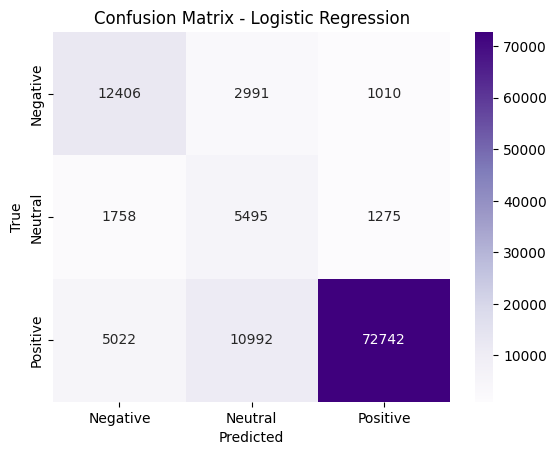

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr, labels=["Negative","Neutral","Positive"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

El modelo de Regresión Logística presenta un buen desempeño diferenciando sentimientos positivos y negativos, con una baja tasa de confusión directa entre ambas clases. Sin embargo, la clase neutral concentra la mayor parte de los errores, actuando como una categoría de transición cuando el modelo no logra identificar claramente la polaridad del comentario. Esta característica impacta negativamente en el F1 macro, aunque el modelo sigue siendo efectivo para la detección de opiniones claramente positivas o negativas.

### Exportación del modelo

Se realiza la exportación del pipeline del modelo ganador (Regresión Logística), que incluye tanto el proceso de vectorización como la ejecución del modelo con los mejores parámetros establecidos.

In [10]:
# Exportacion del pipeline de Regresión Logística

model = joblib.dump(best_lr_model, '../Data-science/models/sentiment_lr.joblib')

NameError: name 'best_lr_model' is not defined